## 1. Load Data

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('MoSe2 PL data 1.txt', sep='\t')
print(df.head())

   2043.53085835571  1.75862073898315
0       2042.582808          1.758621
1       2041.635655         -0.241379
2       2040.689400         -0.241379
3       2039.744041          3.758621
4       2038.799577          3.758621


## 2. Visualize Raw Spectrum

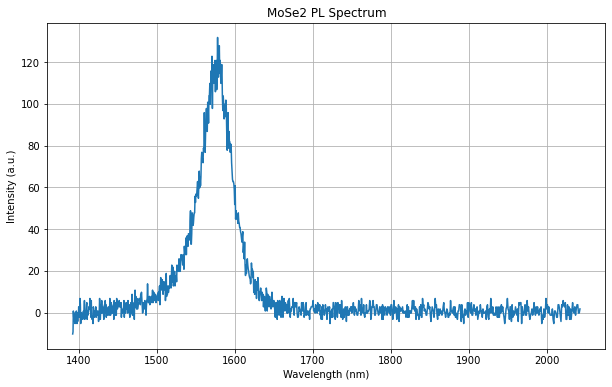

In [25]:
df.columns=['wavelength', 'intensity']

plt.figure(figsize=(10,6))
plt.plot(df['wavelength'], df['intensity'])
plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity (a.u.)')
plt.title('MoSe2 PL Spectrum')
plt.grid(True)
plt.show()

## 3. Noise Filtering & Peak Detection

In [27]:
from scipy.signal import savgol_filter, find_peaks
import numpy as np

df['smoothed'] = savgol_filter(df['intensity'], window_length=11, polyorder=3)
peaks,properties = find_peaks(df['smoothed'],height=50, prominence=20)
peak_wavelengths = df['wavelength'].iloc[peaks].values
peak_intensities = df['smoothed'].iloc[peaks].values

print(f"detected peaks: {len(peaks)}")
for i, (w, i_val) in enumerate(zip(peak_wavelengths, peak_intensities)):
        print(f"peak {i+1}: {w: .2f} nm, intensity : {i_val:.2f}")

detected peaks: 1
peak 1:  1579.56 nm, intensity : 120.35


## 4. FWHM Calculation

In [29]:
peak_idx = peaks[0]
peak_val= df['smoothed'].iloc[peak_idx]
half_max = peak_val / 2
left_side = df['smoothed'].iloc[:peak_idx]
right_side = df['smoothed'].iloc[peak_idx:]

left_idx = (left_side - half_max).abs().idxmin()
right_idx= (right_side - half_max).abs().idxmin()

left_wl = df['wavelength'].iloc[left_idx]
right_wl = df['wavelength'].iloc[right_idx]

fwhm = abs(right_wl - left_wl)

print(f"peak position : {df['wavelength'].iloc[peak_idx]:.2f} nm")
print(f"peak intensity : {peak_val:.2f}")
print(f"Half maxium : {half_max:.2f}")
print(f"FWHM : {fwhm:.2f} nm")

peak position : 1579.56 nm
peak intensity : 120.35
Half maxium : 60.17
FWHM : 44.34 nm


## 5. Final Visualization

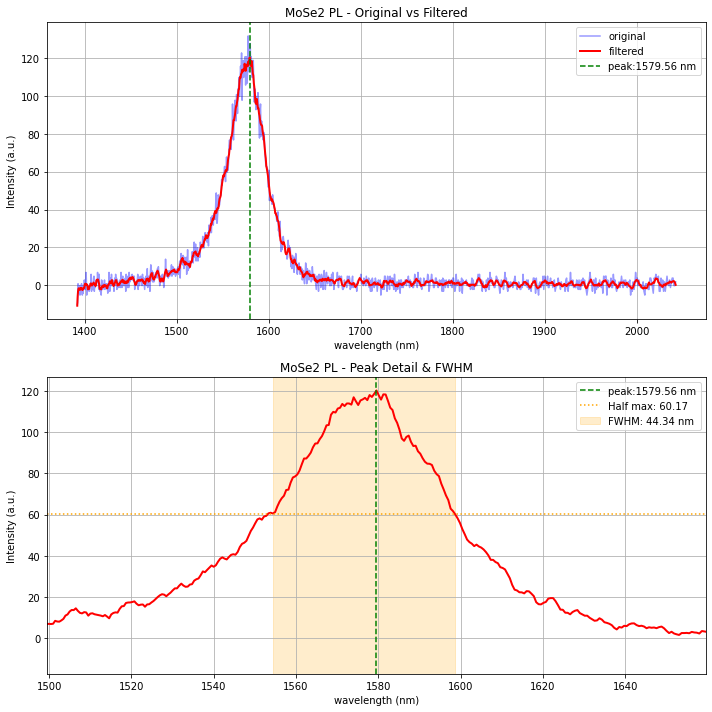

In [31]:
fig, axes = plt.subplots(2,1, figsize=(10,10))

axes[0].plot(df['wavelength'], df['intensity'], alpha=0.4, color = 'blue', label='original')
axes[0].plot(df['wavelength'], df['smoothed'], color='red', linewidth=2, label='filtered')
axes[0].axvline(x=peak_wavelengths[0], color='green', linestyle='--', label=f'peak:{peak_wavelengths[0]:.2f} nm')
axes[0].set_xlabel('wavelength (nm)')
axes[0].set_ylabel('Intensity (a.u.)')
axes[0].set_title('MoSe2 PL - Original vs Filtered')
axes[0].legend()
axes[0].grid(True)

peak_wl = peak_wavelengths[0]
axes[1].plot(df['wavelength'], df['smoothed'], color='red', linewidth=2)
axes[1].axvline(x=peak_wl, color='green', linestyle='--', label=f'peak:{peak_wl:.2f} nm')
axes[1].axhline(y=half_max, color='orange',linestyle=':',label=f'Half max: {half_max:.2f}')
axes[1].axvspan(left_wl, right_wl, alpha=0.2, color='orange', label=f'FWHM: {fwhm:.2f} nm')
axes[1].set_xlim(peak_wl - 80, peak_wl + 80)
axes[1].set_xlabel('wavelength (nm)')
axes[1].set_ylabel('Intensity (a.u.)')
axes[1].set_title('MoSe2 PL - Peak Detail & FWHM')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('MoSe2_PL_analysis.png', dpi=150)
plt.show()

# MoSe2 Photoluminescence Spectrum Analysis

**Author:** YoungBum Kim | PhD in Energy Science (Optics/Nanoscience)  
**Data:** Personal PhD measurement data — WITec confocal Raman/PL system  
**Purpose:** Automated peak detection and quantitative analysis of 2D semiconductor PL spectra

## What this notebook does
1. Loads raw PL spectrum data measured from MoSe2 monolayer
2. Applies Savitzky-Golay filter for noise reduction
3. Automatically detects peak position
4. Calculates FWHM as a sample quality metric

## Key Results
- Peak position: 1579.56 nm (MoSe2 A-exciton)
- FWHM: 44.34 nm